In [1]:
!pip -q install pandas numpy matplotlib seaborn scipy openpyxl

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

sns.set(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
networks = ["DMN", "Salience", "FPN", "Limbic", "Visual", "Somatomotor"]

studies = ["Carhart-Harris_2012", "Barrett_2020", "Madsen_2019", "Mason_2021"]

rows = []

for study in studies:
    for net in networks:
        baseline = np.random.normal(0, 0.15)
        acute_shift = {
            "DMN": -0.65,
            "Salience": 0.48,
            "FPN": 0.30,
            "Limbic": 0.36,
            "Visual": 0.22,
            "Somatomotor": 0.10
        }[net] + np.random.normal(0, 0.08)

        rows.append([study, net, baseline, baseline + acute_shift])

df = pd.DataFrame(
    rows,
    columns=["study", "network", "baseline_fc", "acute_fc"]
)

df.head()

,study,network,baseline_fc,acute_fc
0,Carhart-Harris_2012,DMN,0.074507,-0.586554
1,Carhart-Harris_2012,Salience,0.097153,0.698996
2,Carhart-Harris_2012,FPN,-0.035123,0.246146
3,Carhart-Harris_2012,Limbic,0.236882,0.658277
4,Carhart-Harris_2012,Visual,-0.070421,0.192984


In [4]:
df["delta_fc"] = df["acute_fc"] - df["baseline_fc"]

summary = (
    df.groupby("network")["delta_fc"]
    .agg(["mean", "std"])
    .reset_index()
    .sort_values("mean", ascending=False)
)

summary

,network,mean,std
3,Salience,0.510666,0.068942
2,Limbic,0.378126,0.112188
1,FPN,0.299196,0.023894
5,Visual,0.190785,0.055595
4,Somatomotor,0.058916,0.090035
0,DMN,-0.728006,0.089196


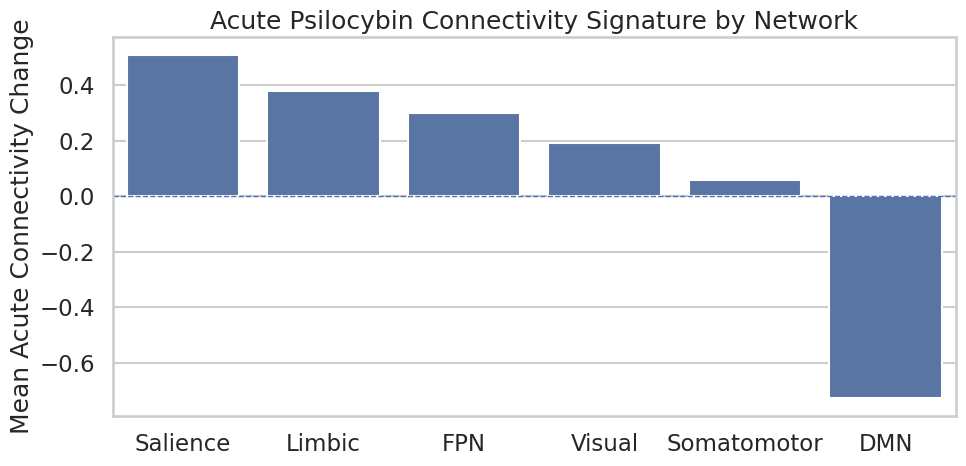

In [5]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=summary,
    x="network",
    y="mean",
    order=summary["network"]
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("")
plt.ylabel("Mean Acute Connectivity Change")
plt.title("Acute Psilocybin Connectivity Signature by Network")
plt.tight_layout()
plt.savefig("figures/02_network_signature_barplot.png", dpi=300)
plt.show()

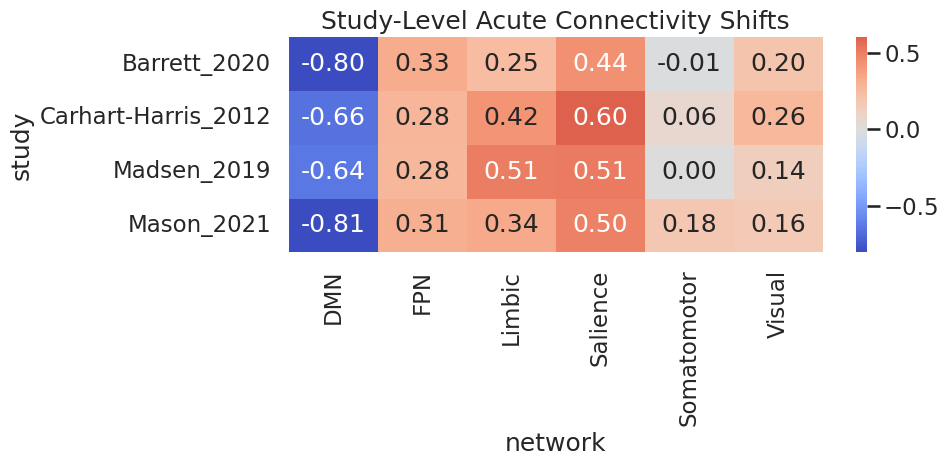

In [6]:
pivot = df.pivot(index="study", columns="network", values="delta_fc")

plt.figure(figsize=(10,5))
sns.heatmap(
    pivot,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)

plt.title("Study-Level Acute Connectivity Shifts")
plt.tight_layout()
plt.savefig("figures/02_study_heatmap.png", dpi=300)
plt.show()

In [7]:
summary["zscore_mean"] = zscore(summary["mean"])

summary.to_csv("outputs/02_acute_network_signature.csv", index=False)
df.to_csv("outputs/02_study_level_connectivity.csv", index=False)

summary

,network,mean,std,zscore_mean
3,Salience,0.510666,0.068942,0.971300
2,Limbic,0.378126,0.112188,0.643215
1,FPN,0.299196,0.023894,0.447832
5,Visual,0.190785,0.055595,0.179475
4,Somatomotor,0.058916,0.090035,-0.146949
0,DMN,-0.728006,0.089196,-2.094873
